In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append("..")
sys.path.append(".")

from custom.augmentations import (
    continuous_perturbation,
    gaussian_pointwise_noise,
    missing_observation,
    pointwise_spike,
    level_shift,
    variance_burst,
    input_only_pair,
    level_shift_input_output_pair,
    variance_burst_input_output_pair,
)

In [2]:
data_path = Path("../dataset/ETT-small/ETTh1.csv")

if not data_path.exists():
    data_path = Path("./dataset/ETT-small/ETTh1.csv")

df = pd.read_csv(data_path)

print(df.shape)
df.head()

(17420, 8)


,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
0,2016-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
1,2016-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001
2,2016-07-01 02:00:00,5.157,1.741,1.279,0.355,3.777,1.218,27.787001
3,2016-07-01 03:00:00,5.090,1.942,1.279,0.391,3.807,1.279,25.044001
4,2016-07-01 04:00:00,5.358,1.942,1.492,0.462,3.868,1.279,21.948000


In [3]:
seq_len = 96
pred_len = 96

value_cols = [col for col in df.columns if col != "date"]
print(value_cols)

start_idx = 1000

x = df[value_cols].iloc[start_idx:start_idx + seq_len].values.astype(np.float32)
y = df[value_cols].iloc[start_idx + seq_len:start_idx + seq_len + pred_len].values.astype(np.float32)

print("x shape:", x.shape)
print("y shape:", y.shape)

['HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'OT']
x shape: (96, 7)
y shape: (96, 7)


In [4]:
seed = 42

x_cont = continuous_perturbation(
    x,
    strength=0.08,
    n_knots=8,
    seed=seed,
)

x_gauss = gaussian_pointwise_noise(
    x,
    ratio=0.10,
    std_scale=0.70,
    seed=seed,
)

x_missing = missing_observation(
    x,
    ratio=0.10,
    fill="mean",
    seed=seed,
)

x_spike = pointwise_spike(
    x,
    ratio=0.05,
    magnitude=4.0,
    seed=seed,
)

x_shift = level_shift(
    x,
    start_ratio=0.60,
    shift_scale=1.0,
    seed=seed,
)

x_var = variance_burst(
    x,
    start_ratio=0.45,
    length_ratio=0.25,
    variance_scale=2.0,
    seed=seed,
)

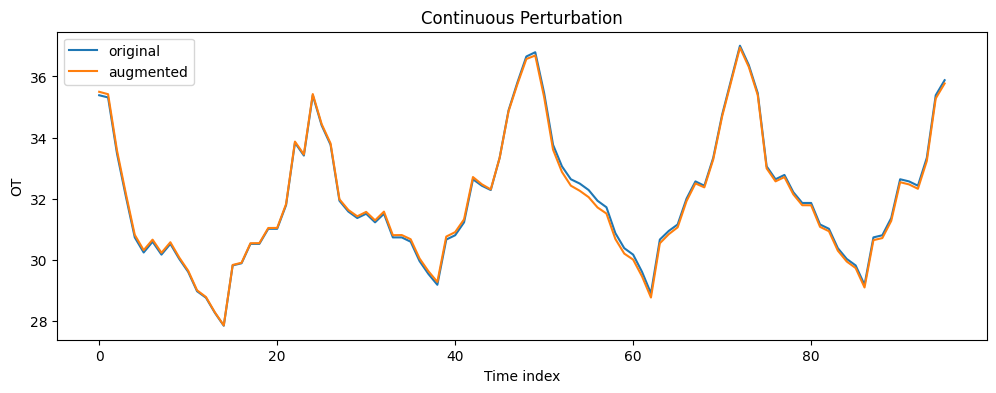

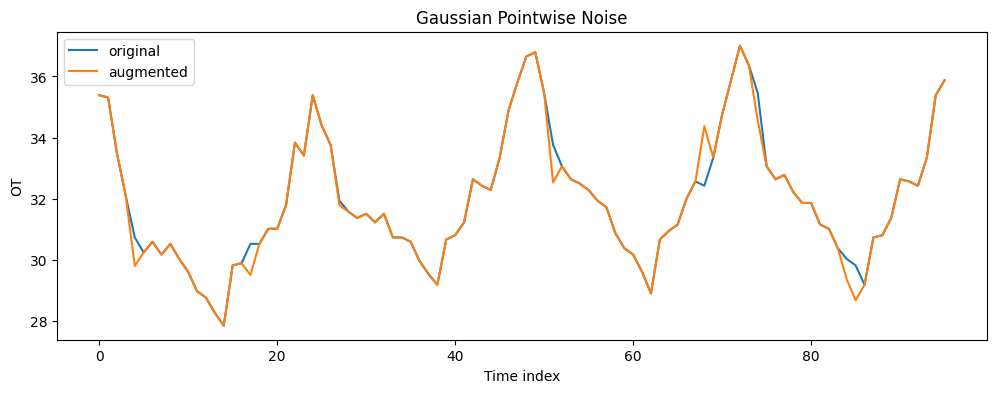

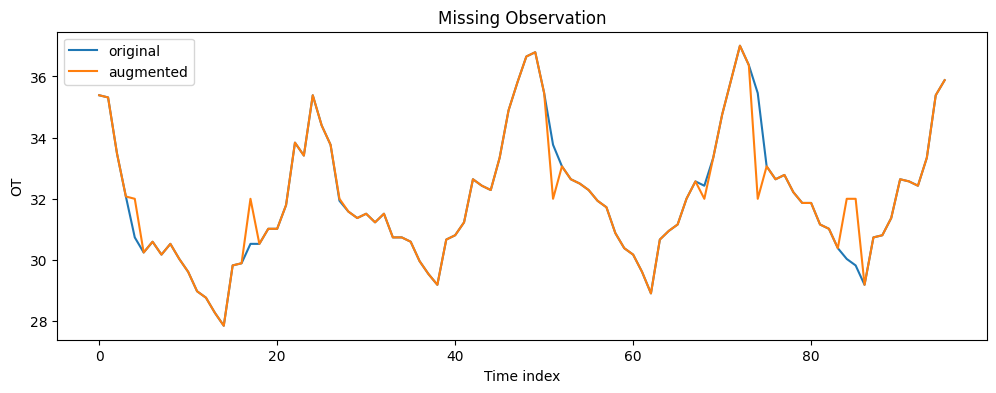

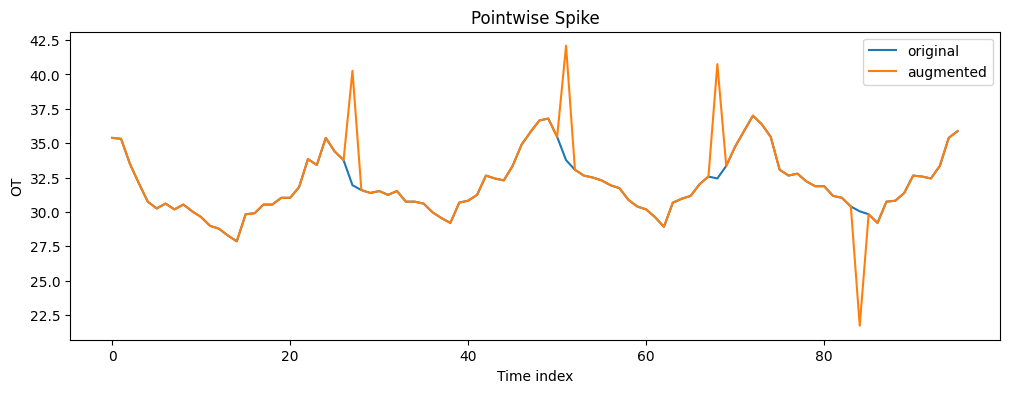

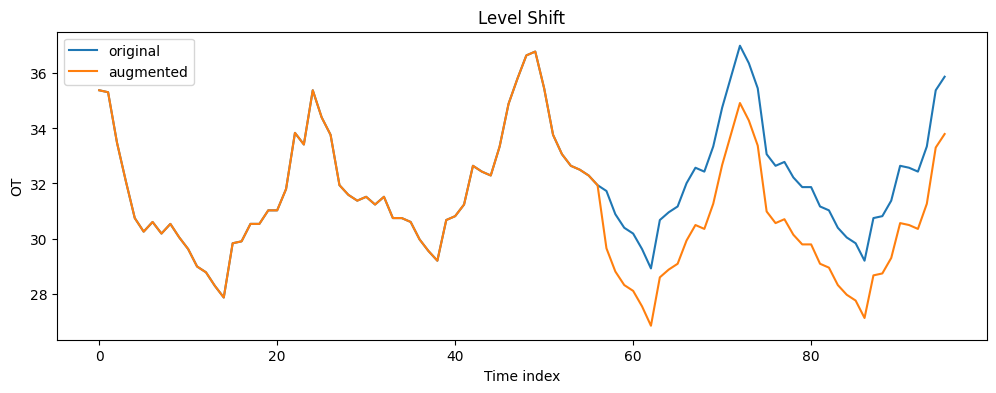

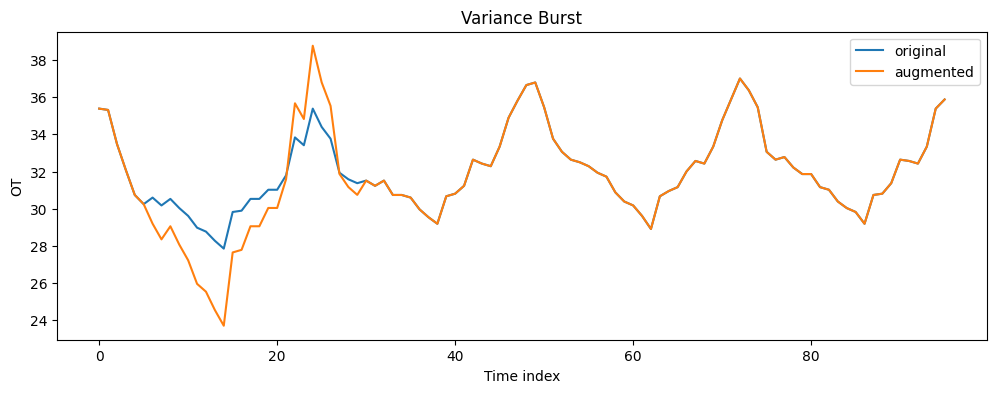

In [5]:
def plot_one(original, augmented, title, feature_name="OT"):
    feature_idx = value_cols.index(feature_name)

    plt.figure(figsize=(12, 4))
    plt.plot(original[:, feature_idx], label="original")
    plt.plot(augmented[:, feature_idx], label="augmented")
    plt.title(title)
    plt.xlabel("Time index")
    plt.ylabel(feature_name)
    plt.legend()
    plt.show()


plot_one(x, x_cont, "Continuous Perturbation")
plot_one(x, x_gauss, "Gaussian Pointwise Noise")
plot_one(x, x_missing, "Missing Observation")
plot_one(x, x_spike, "Pointwise Spike")
plot_one(x, x_shift, "Level Shift")
plot_one(x, x_var, "Variance Burst")

In [6]:
x_aug, y_aug, meta = input_only_pair(
    x,
    y,
    gaussian_pointwise_noise,
    ratio=0.10,
    std_scale=0.70,
    seed=42,
)

print(meta)
print("x changed:", np.mean(np.abs(x_aug - x)))
print("y changed:", np.mean(np.abs(y_aug - y)))

{'type': 'gaussian_pointwise_noise', 'ratio': 0.1, 'std_scale': 0.7, 'independent_channels': False, 'mode': 'input_only'}
x changed: 0.06246786
y changed: 0.0


In [7]:
x_aug, y_aug, meta = level_shift_input_output_pair(
    x,
    y,
    start_ratio=0.60,
    shift_scale=1.0,
    seed=42,
)

print(meta["type"], meta["mode"])
print("x changed:", np.mean(np.abs(x_aug - x)))
print("y changed:", np.mean(np.abs(y_aug - y)))
print("shift shape:", meta["shift"].shape)

level_shift input_output
x changed: 0.5847247
y changed: 1.4393223864691598
shift shape: (1, 1, 7)
